# 1. Objective of Preprocessing

The objective of this notebook is to prepare the cleaned credit card fraud dataset for machine learning.  
This includes loading the dataset, separating features and target, splitting the data into training and testing sets, scaling features, and analyzing the class imbalance problem.  
Since fraud detection datasets are highly imbalanced, this notebook also applies SMOTE to the training data only in order to reduce class imbalance without causing data leakage.

# 2. Import Libraries

In this section, the required Python libraries for preprocessing, visualization, and handling class imbalance are imported.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# 3. Load Clean Dataset

The cleaned dataset is loaded from the local `data` folder.  
After loading, the shape, first few rows, and general structure of the dataset are inspected.

In [2]:
import pandas as pd

df = pd.read_csv("C:\\Users\\lenmo\\Desktop\\school-project\\Credit-Card-Fraud-Detection\\data\\raw\\creditcard.csv")
print(df.shape)
df.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
print("Missing values in dataset:", df.isnull().sum().sum())

Missing values in dataset: 0


# 4. Feature and Target Separation

The dataset is separated into input features (`X`) and target variable (`y`).  
The target column is `Class`, where:

- `0` represents a normal transaction
- `1` represents a fraudulent transaction

In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (284807, 30)
Target vector shape: (284807,)


In [6]:
print("Target distribution:")
print(y.value_counts())

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


# 5. Train-Test Split

The dataset is split into training and testing sets using stratified sampling.  
Stratification is important because it preserves the original fraud-to-non-fraud ratio in both sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (227845, 30)
X_test shape: (56962, 30)
y_train shape: (227845,)
y_test shape: (56962,)


In [8]:
print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Original target distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Training target distribution:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Testing target distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


# 6. Feature Scaling

Feature scaling is applied using `StandardScaler`.  
The scaler is fitted only on the training set and then applied to both training and testing data to avoid data leakage.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training data shape: (227845, 30)
Scaled testing data shape: (56962, 30)


In [10]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
265518,1.411588,0.993379,-0.456037,-0.894052,-0.467284,1.089217,3.024383,-1.194852,0.957057,1.281376,...,-0.173112,0.103171,0.409563,0.490685,1.141970,-0.670832,-0.807227,0.191912,-0.099106,-0.322494
180305,0.623141,1.038507,-0.029349,-2.018302,0.175133,2.133506,2.478840,-0.001832,0.566704,0.041121,...,-0.293564,0.052055,0.314019,0.056568,1.168583,0.985238,-0.977976,0.006397,-0.211524,-0.339764
42664,-1.130680,-0.506766,0.366065,0.470114,-0.700918,-0.598748,1.470411,-1.786684,-4.227592,0.000064,...,1.663010,-3.807987,0.150500,-0.695838,-1.540549,1.587269,1.895777,0.094137,0.566426,0.346693
198723,0.794699,1.166419,-0.909447,-0.493095,-1.178149,-1.010692,-0.262292,-1.153123,0.008765,-1.019866,...,-0.635236,-0.190540,0.105701,0.331932,-0.888718,-0.532153,-0.336546,0.044738,-0.193183,-0.327360
82325,-0.748102,-0.229485,-0.613041,0.076742,-2.440089,0.518711,-0.109914,0.407186,-0.095161,-0.041449,...,-0.355860,-0.331467,-0.239208,-0.010747,-2.250223,-0.559400,-0.300345,-0.080285,-0.196818,-0.008281


# 7. Class Imbalance Problem

Fraud detection datasets are usually highly imbalanced because fraudulent transactions are very rare compared to normal transactions.  
This imbalance can cause machine learning models to become biased toward the majority class.  
Therefore, the class distribution is inspected before applying any balancing technique.

In [11]:
print("Class distribution in full dataset:")
print(Counter(y))

print("\nClass distribution in training set:")
print(Counter(y_train))

print("\nClass distribution in testing set:")
print(Counter(y_test))

Class distribution in full dataset:
Counter({0: 284315, 1: 492})

Class distribution in training set:
Counter({0: 227451, 1: 394})

Class distribution in testing set:
Counter({0: 56864, 1: 98})


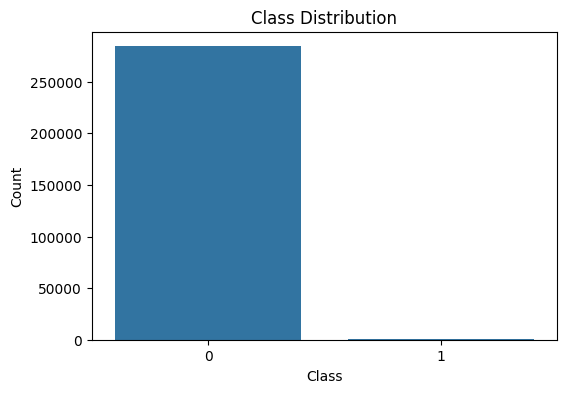

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The output above shows that the dataset is highly imbalanced.  
This means that accuracy alone is not a reliable evaluation metric, because a model may predict the majority class most of the time and still achieve high accuracy.

# 8. Apply SMOTE to Training Data

To reduce the imbalance in the training set, SMOTE (Synthetic Minority Over-sampling Technique) is applied.  
SMOTE is used only on the training data, not on the testing data, to prevent data leakage and preserve fair model evaluation.

In [13]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))

Before SMOTE: Counter({0: 227451, 1: 394})
After SMOTE: Counter({0: 227451, 1: 227451})


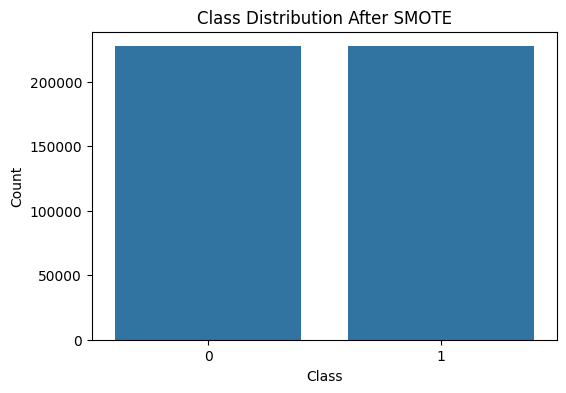

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 9. Final Processed Data Overview

After preprocessing, the dataset is now ready for model training.  
The following processed datasets are available:

- `X_train_scaled`
- `X_test_scaled`
- `y_train`
- `y_test`
- `X_train_resampled`
- `y_train_resampled`

These outputs can be used in the next notebook for baseline modeling.

In [15]:
print("Final processed datasets:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("X_train_resampled:", X_train_resampled.shape)
print("y_train_resampled:", y_train_resampled.shape)

Final processed datasets:
X_train_scaled: (227845, 30)
X_test_scaled: (56962, 30)
y_train: (227845,)
y_test: (56962,)
X_train_resampled: (454902, 30)
y_train_resampled: (454902,)


# 10. Optional Save Processed Data

The processed datasets can be saved for use in later notebooks or model training scripts.

In [16]:
import os
import pandas as pd

# Create processed folder if not exists
os.makedirs("../data/processed", exist_ok=True)

# ===== Save scaled data =====
X_train_scaled.to_csv("../data/processed/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("../data/processed/X_test_scaled.csv", index=False)

y_train.to_frame(name="Class").to_csv("../data/processed/y_train.csv", index=False)
y_test.to_frame(name="Class").to_csv("../data/processed/y_test.csv", index=False)

# ===== Save resampled data =====
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns)

X_train_resampled_df.to_csv("../data/processed/X_train_resampled.csv", index=False)
pd.Series(y_train_resampled, name="Class").to_csv("../data/processed/y_train_resampled.csv", index=False)

print("Processed files saved successfully.")

Processed files saved successfully.


In [17]:
import joblib
os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [19]:
X_train.to_csv("../data/processed/X_train_raw.csv", index=False)
X_test.to_csv("../data/processed/X_test_raw.csv", index=False)

# 11. Summary of Preprocessing Decisions

The following preprocessing steps were performed in this notebook:

1. The cleaned credit card fraud dataset was loaded successfully.
2. Features and target variable were separated.
3. The dataset was split into training and testing sets using stratified sampling.
4. Feature scaling was performed using `StandardScaler`, fitted only on the training set.
5. The class imbalance problem was analyzed and visualized.
6. SMOTE was applied only to the training data to balance the minority fraud class.
7. The processed data is now ready for the next stage of machine learning model development.

These preprocessing decisions help ensure that the modeling stage is both fair and free from data leakage.